#                                                                 **Insurance Cost Prediction**                                        

# **OBJECTIVE**

The objective of this project is to develop a machine learning model that accurately predicts individual health insurance premiums based on demographic and medical attributes such as age, BMI, chronic conditions, and medical history.

The goal is to move beyond traditional pricing methods by leveraging data-driven insights to provide more personalized, fair, and accurate premium estimates.

Additionally, the project aims to analyze key factors influencing insurance costs and deploy a user-friendly application that allows real-time premium prediction.

# **Load & Understand Data**

In [ ]:
import pandas as pd

In [ ]:
!gdown "1NBk1TFkK4NeKdodR2DxIdBp2Mk1mh4AS"

Downloading...
From: https://drive.google.com/uc?id=1NBk1TFkK4NeKdodR2DxIdBp2Mk1mh4AS
To: /content/insurance.csv
100% 30.8k/30.8k [00:00<00:00, 3.80MB/s]


In [ ]:
df = pd.read_csv("insurance.csv")

In [ ]:
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


In [ ]:
df.describe()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,41.745436,0.419878,0.468560,0.055781,0.180527,168.182556,76.950304,0.215010,0.117647,0.667343,24336.713996
std,13.963371,0.493789,0.499264,0.229615,0.384821,10.098155,14.265096,0.411038,0.322353,0.749205,6248.184382
min,18.000000,0.000000,0.000000,0.000000,0.000000,145.000000,51.000000,0.000000,0.000000,0.000000,15000.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,21000.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,75.000000,0.000000,0.000000,1.000000,23000.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,87.000000,0.000000,0.000000,1.000000,28000.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,40000.000000


# **Feature Engineering**

In [ ]:
df['BMI'] = df['Weight'] / ((df['Height']/100)**2)

In [ ]:
df['Risk_Score'] = (
    df['Diabetes'] +
    df['BloodPressureProblems'] +
    df['AnyChronicDiseases'] +
    df['AnyTransplants'] +
    df['NumberOfMajorSurgeries']
)

# **EDA**(Exploratory data analysis)

# **UNIVARIATE ANALYSIS**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

1. **PremiumPrice Distribution**

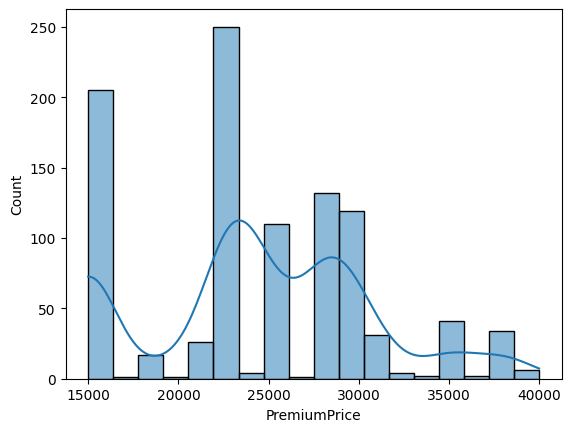

In [ ]:
sns.histplot(df['PremiumPrice'], kde=True)
plt.show()

Premium distribution is right-skewed, indicating presence of high-risk individuals with significantly higher costs.

2. **Age Distribution**

<Axes: xlabel='Age', ylabel='Count'>

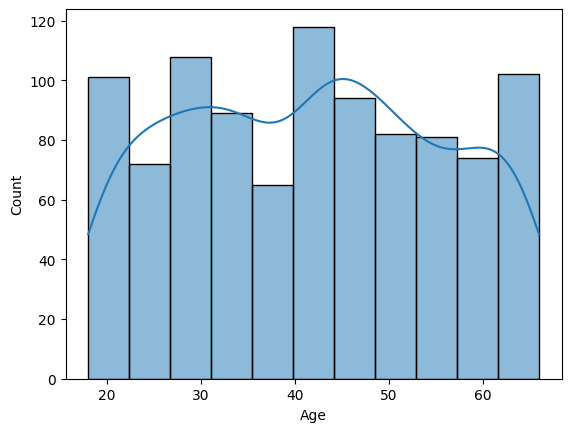

In [ ]:
sns.histplot(df['Age'], kde=True)

<Axes: xlabel='NumberOfMajorSurgeries', ylabel='count'>

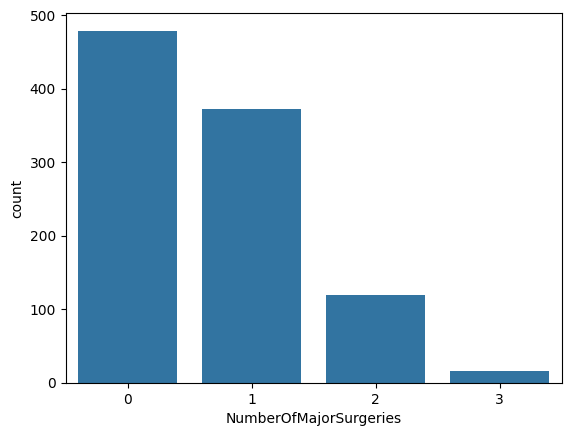

In [ ]:
sns.countplot(x='NumberOfMajorSurgeries', data=df)

Most people have 0 or 1 surgeries?

# **BIVARIATE ANALYSIS**

**Surgeries vs Premium**

<Axes: xlabel='NumberOfMajorSurgeries', ylabel='PremiumPrice'>

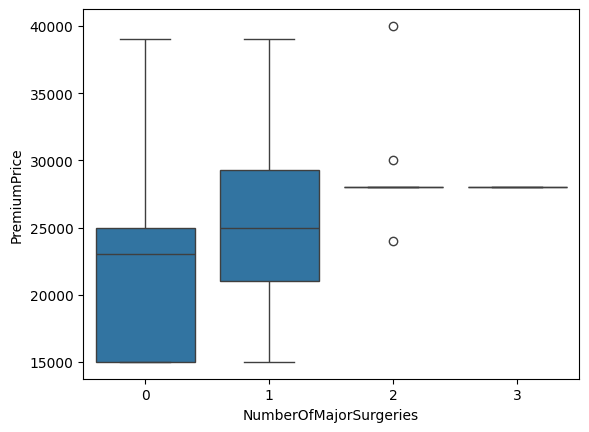

In [ ]:
sns.boxplot(x='NumberOfMajorSurgeries', y='PremiumPrice', data=df)

Premium increases significantly as number of surgeries increases

# 2. **Diabetes vs Premium**

<Axes: xlabel='Diabetes', ylabel='PremiumPrice'>

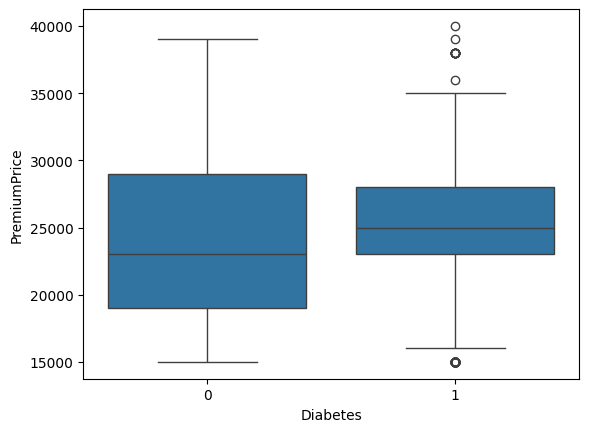

In [ ]:
sns.boxplot(x='Diabetes', y='PremiumPrice', data=df)

Diabetic people - higher premium

# 3. **Chronic Disease vs Premium**

<Axes: xlabel='AnyChronicDiseases', ylabel='PremiumPrice'>

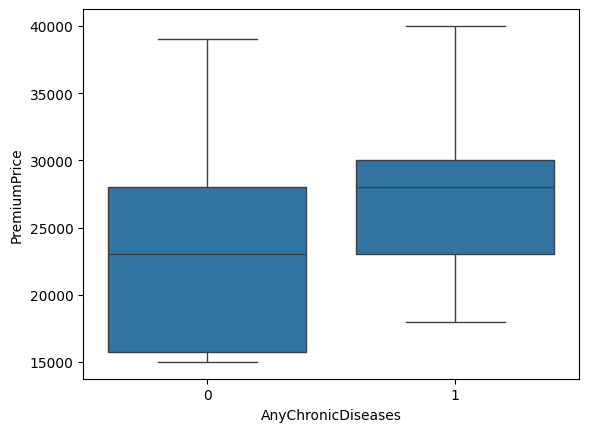

In [ ]:
sns.boxplot(x='AnyChronicDiseases', y='PremiumPrice', data=df)

# 4. **BMI vs Premium**

<Axes: xlabel='BMI', ylabel='PremiumPrice'>

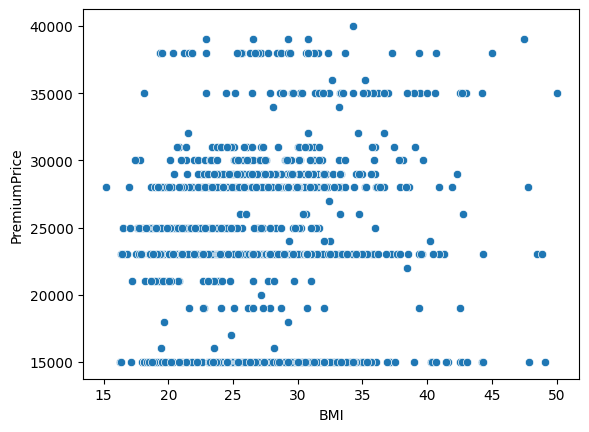

In [ ]:
sns.scatterplot(x='BMI', y='PremiumPrice', data=df)

# 5. **Age vs Premium**

<Axes: xlabel='Age', ylabel='PremiumPrice'>

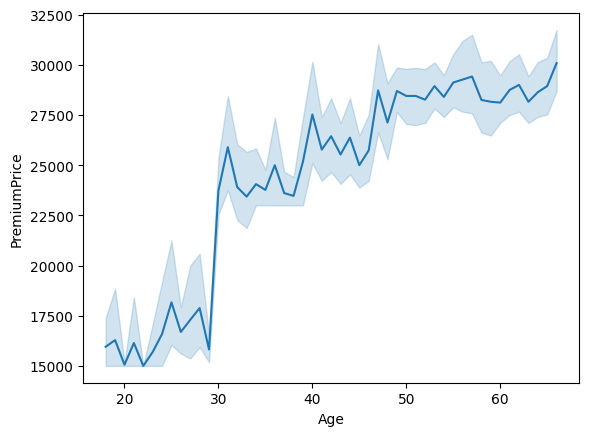

In [ ]:
sns.lineplot(x='Age', y='PremiumPrice', data=df)

Age (increase) - Premium (increase)

# **CORRELATION ANALYSIS**

<Axes: >

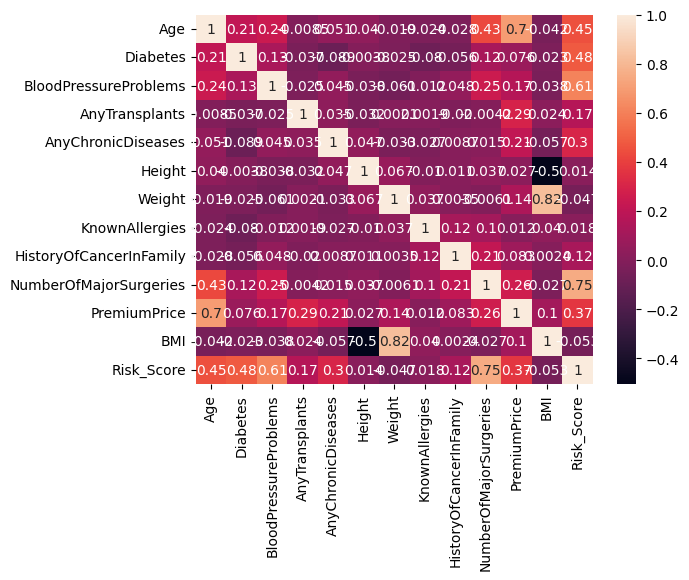

In [ ]:
sns.heatmap(df.corr(), annot=True)

Which features have highest correlation with Premium

# **OUTLIER DETECTION**

<Axes: ylabel='PremiumPrice'>

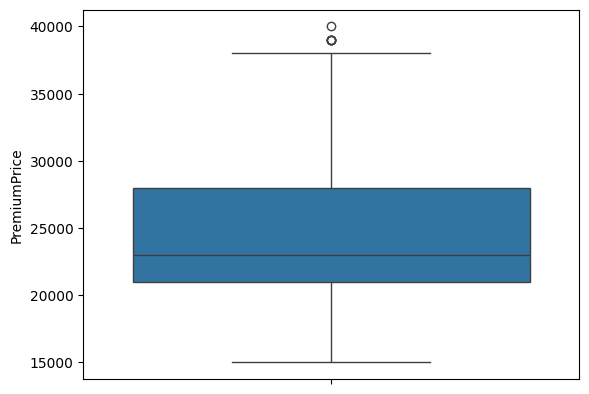

In [ ]:
sns.boxplot(df['PremiumPrice'])

1. Outliers can break model
* Example : Premium > 38,000 - extreme cases

# **HYPOTHESIS TESTING**

**TEST 1: Diabetes vs Premium**

In [ ]:
from scipy.stats import ttest_ind

group1 = df[df['Diabetes']==1]['PremiumPrice']
group2 = df[df['Diabetes']==0]['PremiumPrice']

stat, p = ttest_ind(group1, group2)

print("p-value:", p)

p-value: 0.01669009138530611


**TEST 2: Chronic Disease vs Premium**

In [ ]:
from scipy.stats import ttest_ind

group1 = df[df['AnyChronicDiseases']==1]['PremiumPrice']
group2 = df[df['AnyChronicDiseases']==0]['PremiumPrice']

stat, p = ttest_ind(group1, group2)

print("p-value:", p)

p-value: 3.713413765291482e-11


**TEST 3: Surgeries vs Premium**

In [ ]:
from scipy.stats import f_oneway

g0 = df[df['NumberOfMajorSurgeries']==0]['PremiumPrice']
g1 = df[df['NumberOfMajorSurgeries']==1]['PremiumPrice']
g2 = df[df['NumberOfMajorSurgeries']==2]['PremiumPrice']

stat, p = f_oneway(g0, g1, g2)

print("p-value:", p)

p-value: 1.1621633318361831e-15


**TEST 4: BMI vs Premium**

In [ ]:
import statsmodels.api as sm

X = df[['BMI']]
X = sm.add_constant(X)
y = df['PremiumPrice']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           PremiumPrice   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     10.72
Date:                Tue, 21 Apr 2026   Prob (F-statistic):            0.00110
Time:                        10:54:21   Log-Likelihood:                -10011.
No. Observations:                 986   AIC:                         2.003e+04
Df Residuals:                     984   BIC:                         2.004e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.131e+04    946.360     22.514      0.0

# **ML MODELING**

* **DATA PREPROCESSING**

Separate Features & Target

In [ ]:
X = df.drop('PremiumPrice', axis=1)
y = df['PremiumPrice']

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

* **BASELINE MODEL (Linear Regression)**

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred_lr)
print("RMSE:", np.sqrt(mse))
print("R2:", r2_score(y_test, y_pred_lr))

RMSE: 3494.4137981898157
R2: 0.7136461439649741


**ADVANCED MODELS**

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

**MODEL COMPARISON**

In [ ]:
print("Linear R2:", r2_score(y_test, y_pred_lr))
print("RF R2:", r2_score(y_test, y_pred_rf))
print("GB R2:", r2_score(y_test, y_pred_gb))

Linear R2: 0.7136461439649741
RF R2: 0.8939828631724019
GB R2: 0.8698772881878454


**FEATURE IMPORTANCE**

<Axes: >

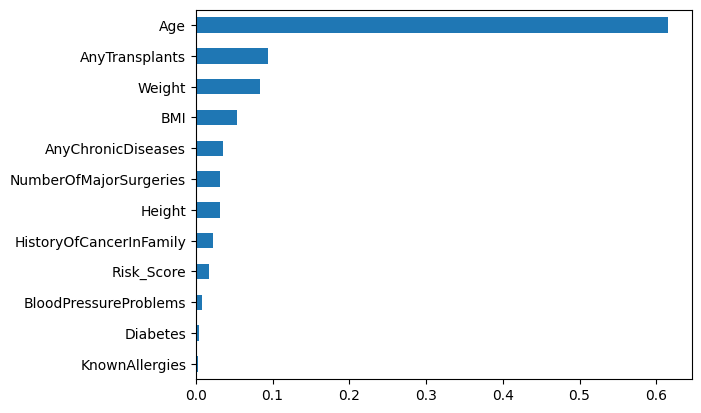

In [ ]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

In [ ]:
pip install shap

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(rf)

In [ ]:
shap_values = explainer.shap_values(X_test)

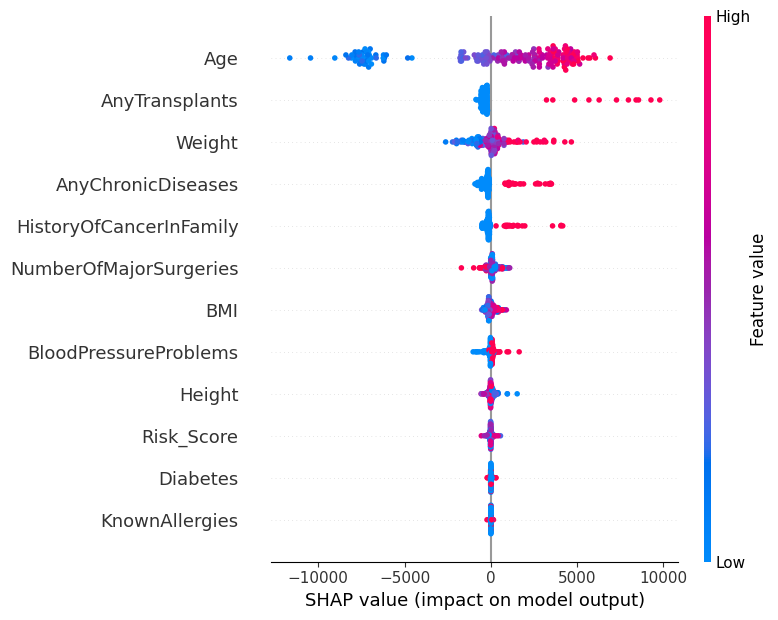

In [ ]:
shap.summary_plot(shap_values, X_test)

# **BUSINESS INSIGHTS**

1. Risk-Based Pricing

* Customers with higher medical risks (such as surgeries, chronic diseases, and high BMI) tend to have significantly higher insurance premiums.
* This helps insurers price policies more accurately based on actual risk.

2. Key Cost Drivers

* Number of major surgeries, BMI, and chronic conditions are the most influential factors.
* Insurance companies can focus on these variables for better risk assessment.

3. Customer Segmentation

* Customers can be grouped into low-risk and high-risk categories using health data.
* Enables targeted pricing strategies and personalized plans.

4. Improved Profitability

* More accurate predictions reduce underpricing (losses) and overpricing (customer churn).
* Leads to better financial stability for insurers.

5. Personalized Insurance Plans

* Using model predictions, companies can design customized insurance packages.
* Improves customer satisfaction and trust.

6. Decision Support System

* The deployed model can assist agents and companies in making quick and informed decisions.
* Reduces dependency on manual estimation methods.

# **CONCLUSION**

This project demonstrates a complete end-to-end machine learning workflow for predicting health insurance premiums using individual-level data. By analyzing various demographic and medical attributes such as age, BMI, chronic conditions, and number of surgeries, the model is able to capture important patterns that influence insurance costs.

The Random Forest model performed well, achieving a good balance between accuracy and generalization, with a strong R² score indicating that a significant portion of the variability in premium pricing is explained by the model.

Feature analysis revealed that medical history, especially the number of major surgeries, along with BMI and overall health risk, are key drivers of premium pricing. The deployment of the model using Streamlit further enhances its usability by allowing real-time predictions based on user input.

Overall, this project highlights how machine learning can be effectively applied to build practical, data-driven solutions for real-world problems like insurance pricing.

In [ ]:
import pickle

pickle.dump(rf, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))